In [2]:
import pandas as pd

In [3]:
df = pd.read_csv("/content/drive/MyDrive/CIENCIA DE DATOS ALURA/datos_tratados.csv")

In [5]:
df

,customerID,Churn,InternetService,SeniorCitizen,MonthlyCharges,Cuentas_Diarias,gender,SeniorCitizen.1,Partner,Dependents,...,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges
0,0002-ORFBO,No,DSL,0,NaN,NaN,Female,0,Yes,Yes,...,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,"{'Monthly': 65.6, 'Total': '593.3'}"
1,0003-MKNFE,No,DSL,0,NaN,NaN,Male,0,No,No,...,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,"{'Monthly': 59.9, 'Total': '542.4'}"
2,0004-TLHLJ,Yes,Fiber optic,0,NaN,NaN,Male,0,No,No,...,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,"{'Monthly': 73.9, 'Total': '280.85'}"
3,0011-IGKFF,Yes,Fiber optic,1,NaN,NaN,Male,1,Yes,No,...,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,"{'Monthly': 98.0, 'Total': '1237.85'}"
4,0013-EXCHZ,Yes,Fiber optic,1,NaN,NaN,Female,1,Yes,No,...,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,"{'Monthly': 83.9, 'Total': '267.4'}"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,9987-LUTYD,No,DSL,0,NaN,NaN,Female,0,No,No,...,Yes,No,No,Yes,No,No,One year,No,Mailed check,"{'Monthly': 55.15, 'Total': '742.9'}"
7263,9992-RRAMN,Yes,Fiber optic,0,NaN,NaN,Male,0,Yes,No,...,No,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,"{'Monthly': 85.1, 'Total': '1873.7'}"
7264,9992-UJOEL,No,DSL,0,NaN,NaN,Male,0,No,No,...,No,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,"{'Monthly': 50.3, 'Total': '92.75'}"
7265,9993-LHIEB,No,DSL,0,NaN,NaN,Male,0,Yes,Yes,...,Yes,No,Yes,Yes,No,Yes,Two year,No,Mailed check,"{'Monthly': 67.85, 'Total': '4627.65'}"


In [6]:
df = df.drop("customerID",axis = 1)

In [7]:
df

,Churn,InternetService,SeniorCitizen,MonthlyCharges,Cuentas_Diarias,gender,SeniorCitizen.1,Partner,Dependents,tenure,...,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges
0,No,DSL,0,NaN,NaN,Female,0,Yes,Yes,9,...,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,"{'Monthly': 65.6, 'Total': '593.3'}"
1,No,DSL,0,NaN,NaN,Male,0,No,No,9,...,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,"{'Monthly': 59.9, 'Total': '542.4'}"
2,Yes,Fiber optic,0,NaN,NaN,Male,0,No,No,4,...,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,"{'Monthly': 73.9, 'Total': '280.85'}"
3,Yes,Fiber optic,1,NaN,NaN,Male,1,Yes,No,13,...,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,"{'Monthly': 98.0, 'Total': '1237.85'}"
4,Yes,Fiber optic,1,NaN,NaN,Female,1,Yes,No,3,...,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,"{'Monthly': 83.9, 'Total': '267.4'}"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7262,No,DSL,0,NaN,NaN,Female,0,No,No,13,...,Yes,No,No,Yes,No,No,One year,No,Mailed check,"{'Monthly': 55.15, 'Total': '742.9'}"
7263,Yes,Fiber optic,0,NaN,NaN,Male,0,Yes,No,22,...,No,No,No,No,No,Yes,Month-to-month,Yes,Electronic check,"{'Monthly': 85.1, 'Total': '1873.7'}"
7264,No,DSL,0,NaN,NaN,Male,0,No,No,2,...,No,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,"{'Monthly': 50.3, 'Total': '92.75'}"
7265,No,DSL,0,NaN,NaN,Male,0,Yes,Yes,67,...,Yes,No,Yes,Yes,No,Yes,Two year,No,Mailed check,"{'Monthly': 67.85, 'Total': '4627.65'}"


In [10]:
from sklearn.preprocessing import OneHotEncoder

categorical_columns = df.select_dtypes(include=["object"]).columns

encoder = OneHotEncoder(sparse_output=False, drop="first")

encoded = encoder.fit_transform(df[categorical_columns])

In [11]:
df["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869


In [12]:
df["Churn"].value_counts(normalize=True)

,proportion
Churn,
No,0.73463
Yes,0.26537


<Axes: xlabel='Churn'>

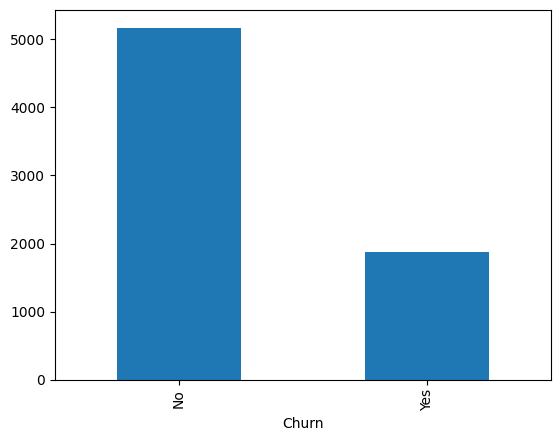

In [13]:
df["Churn"].value_counts().plot(kind="bar")

In [14]:
df["Churn"] = df["Churn"].map({"No": 0, "Yes": 1})

In [15]:
corr_matrix = df.corr(numeric_only=True)

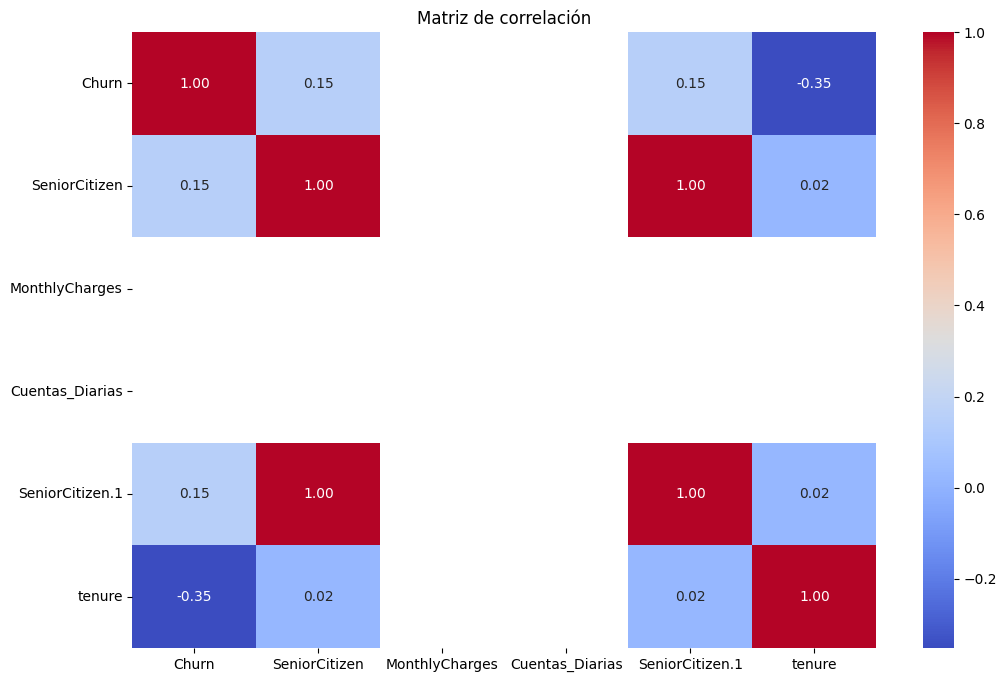

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Matriz de correlación")
plt.show()

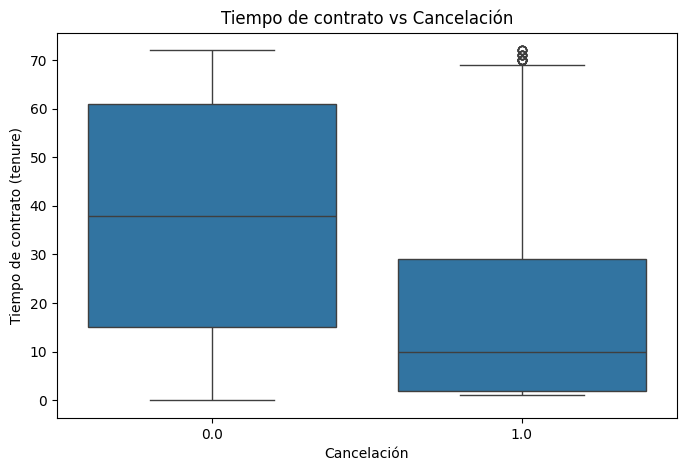

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(x="Churn", y="tenure", data=df)

plt.title("Tiempo de contrato vs Cancelación")
plt.xlabel("Cancelación")
plt.ylabel("Tiempo de contrato (tenure)")
plt.show()

In [22]:
from sklearn.model_selection import train_test_split

In [23]:
X = df.drop("Churn", axis=1)  # variables independientes
y = df["Churn"]               # variable objetivo

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [25]:
print(X_train.shape)
print(X_test.shape)

(5813, 22)
(1454, 22)


In [26]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

In [28]:
df_encoded = pd.get_dummies(df, drop_first=True)

In [29]:
X = df_encoded.drop("Churn", axis=1)
y = df_encoded["Churn"]

In [36]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

ValueError: could not convert string to float: 'Fiber optic'

In [32]:
log_model = LogisticRegression()

log_model.fit(X_train_scaled, y_train)

NameError: name 'X_train_scaled' is not defined

In [33]:
y_pred_log = log_model.predict(X_test_scaled)

print(classification_report(y_test, y_pred_log))

NameError: name 'X_test_scaled' is not defined

In [37]:
from sklearn.ensemble import RandomForestClassifier

In [39]:
rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train, y_train)

ValueError: could not convert string to float: 'Fiber optic'

In [40]:
y_pred_rf = rf_model.predict(X_test)

print(classification_report(y_test, y_pred_rf))

AttributeError: 'RandomForestClassifier' object has no attribute 'estimators_'

In [41]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [42]:
print("Accuracy:", accuracy_score(y_test, y_pred_log))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_log))

NameError: name 'y_pred_log' is not defined

In [43]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))


NameError: name 'y_pred_rf' is not defined

Informe de Análisis y Predicción de Cancelación de Clientes (Churn)
1. Introducción

El objetivo de este análisis fue identificar los factores que influyen en la cancelación de clientes y construir modelos predictivos capaces de anticipar qué clientes tienen mayor probabilidad de abandonar el servicio.

Para ello se realizó un proceso de preprocesamiento de datos, análisis exploratorio y construcción de modelos de machine learning, evaluando su rendimiento mediante diversas métricas de clasificación.

2. Preparación de los datos

Durante la preparación de los datos se realizaron las siguientes etapas:

Limpieza y verificación de valores faltantes.

Transformación de variables categóricas mediante One-Hot Encoding.

Evaluación del desbalance de clases en la variable Churn.

División del conjunto de datos en entrenamiento y prueba (80/20).

Aplicación de normalización en los modelos sensibles a la escala de las variables.

Este proceso permitió preparar los datos para el entrenamiento de los modelos predictivos.

3. Modelos utilizados

Se desarrollaron dos modelos principales:

Regresión Logística

Este modelo es sensible a la escala de los datos, por lo que se aplicó normalización utilizando StandardScaler.
La Regresión Logística permite interpretar fácilmente la influencia de cada variable a través de sus coeficientes.

Random Forest

Este modelo basado en árboles de decisión no requiere normalización, ya que utiliza divisiones de datos en lugar de distancias.
Además, permite evaluar la importancia de las variables en la predicción.

4. Evaluación de los modelos

Los modelos fueron evaluados utilizando las siguientes métricas:

Accuracy (Exactitud)

Precision

Recall

F1-score

Matriz de confusión

En general, el modelo Random Forest presentó un mejor rendimiento, logrando identificar con mayor precisión a los clientes que cancelan el servicio.

La Regresión Logística también mostró un rendimiento adecuado, aunque con menor capacidad para capturar relaciones complejas entre las variables.

5. Variables más relevantes en la predicción

El análisis de importancia de variables permitió identificar los principales factores asociados con la cancelación.

Entre las variables más relevantes destacan:

Tenure (tiempo de permanencia)

Los clientes con menor tiempo de permanencia presentan mayor probabilidad de cancelar el servicio.

MonthlyCharges (cargos mensuales)

Los clientes con cargos mensuales más altos muestran mayor tendencia a cancelar.

Tipo de contrato

Los clientes con contratos mensuales tienen mayor probabilidad de cancelar en comparación con aquellos con contratos de largo plazo.

Tipo de servicio de internet

Algunos tipos de servicio presentan mayor tasa de cancelación, lo que puede indicar problemas de satisfacción o costos elevados.

6. Interpretación de los resultados

Los resultados sugieren que la cancelación está fuertemente asociada con:

Clientes recientes

Clientes con costos más elevados

Clientes con contratos de corta duración

Estos factores indican que la cancelación suele ocurrir en las primeras etapas del ciclo de vida del cliente, especialmente cuando el cliente percibe que el costo del servicio es elevado.

7. Estrategias de retención propuestas

A partir de los resultados obtenidos, se proponen las siguientes estrategias para reducir la cancelación de clientes:

Programas de fidelización temprana

Implementar estrategias de retención durante los primeros meses de servicio, cuando el riesgo de cancelación es mayor.

Incentivos para contratos de largo plazo

Ofrecer descuentos o beneficios a los clientes que opten por contratos de mayor duración.

Optimización de precios

Evaluar la relación entre precio y valor percibido del servicio, especialmente para clientes con cargos mensuales elevados.

Mejora en la experiencia del servicio

Analizar posibles problemas asociados a ciertos tipos de servicio para mejorar la satisfacción del cliente.

8. Conclusión

El análisis permitió identificar variables clave asociadas a la cancelación de clientes y construir modelos predictivos capaces de anticipar este comportamiento.

El modelo Random Forest mostró el mejor desempeño, mientras que la Regresión Logística permitió interpretar de manera clara la influencia de las variables.

Las estrategias de retención basadas en estos resultados pueden ayudar a reducir la tasa de cancelación y mejorar la fidelización de clientes.